In [32]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output # Only for iPython

#Helper function

In [33]:
def crossMat(a):
    """
    Returns the cross product matrix of vector 'a'.

    Parameters:
    a : np.ndarray
        A 3-element array representing a vector.

    Returns:
    A : np.ndarray
        The cross product matrix corresponding to vector 'a'.
    """
    A = np.array([[0, -a[2], a[1]],
                  [a[2], 0, -a[0]],
                  [-a[1], a[0], 0]])

    return A

#Gradient and Hessian of elastic energies

In [34]:
def gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the derivative of bending energy E_k^b with respect to
    x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dF : np.ndarray
        Derivative of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0.0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Gradient of bending energy
    dkappa = kappa1 - kappaBar
    dF = gradKappa * EI * dkappa / l_k

    return dF

In [35]:
def hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the Hessian (second derivative) of bending energy E_k^b
    with respect to x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dJ : np.ndarray
        Hessian of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Compute the Hessian (second derivative of kappa)
    DDkappa1 = np.zeros((6, 6))

    norm2_e = norm_e**2
    norm2_f = norm_f**2

    Id3 = np.eye(3)

    # Helper matrices for second derivatives
    tt_o_tt = np.outer(tilde_t, tilde_t)
    tmp = np.cross(tf, tilde_d2)
    tf_c_d2t_o_tt = np.outer(tmp, tilde_t)
    kb_o_d2e = np.outer(kb, m2e)

    D2kappa1De2 = (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt - tf_c_d2t_o_tt.T) / norm2_e - \
                  kappa1 / (chi * norm2_e) * (Id3 - np.outer(te, te)) + \
                  (kb_o_d2e + kb_o_d2e.T) / (4 * norm2_e)

    tmp = np.cross(te, tilde_d2)
    te_c_d2t_o_tt = np.outer(tmp, tilde_t)
    tt_o_te_c_d2t = te_c_d2t_o_tt.T
    kb_o_d2f = np.outer(kb, m2f)

    D2kappa1Df2 = (2 * kappa1 * tt_o_tt + te_c_d2t_o_tt + te_c_d2t_o_tt.T) / norm2_f - \
                  kappa1 / (chi * norm2_f) * (Id3 - np.outer(tf, tf)) + \
                  (kb_o_d2f + kb_o_d2f.T) / (4 * norm2_f)
    D2kappa1DeDf = -kappa1 / (chi * norm_e * norm_f) * (Id3 + np.outer(te, tf)) \
                  + 1.0 / (norm_e * norm_f) * (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt + \
                  tt_o_te_c_d2t - crossMat(tilde_d2))
    D2kappa1DfDe = D2kappa1DeDf.T

    # Populate the Hessian of kappa
    DDkappa1[0:2, 0:2] = D2kappa1De2[0:2, 0:2]
    DDkappa1[0:2, 2:4] = -D2kappa1De2[0:2, 0:2] + D2kappa1DeDf[0:2, 0:2]
    DDkappa1[0:2, 4:6] = -D2kappa1DeDf[0:2, 0:2]
    DDkappa1[2:4, 0:2] = -D2kappa1De2[0:2, 0:2] + D2kappa1DfDe[0:2, 0:2]
    DDkappa1[2:4, 2:4] = D2kappa1De2[0:2, 0:2] - D2kappa1DeDf[0:2, 0:2] - \
                         D2kappa1DfDe[0:2, 0:2] + D2kappa1Df2[0:2, 0:2]
    DDkappa1[2:4, 4:6] = D2kappa1DeDf[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 0:2] = -D2kappa1DfDe[0:2, 0:2]
    DDkappa1[4:6, 2:4] = D2kappa1DfDe[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 4:6] = D2kappa1Df2[0:2, 0:2]

    # Hessian of bending energy
    dkappa = kappa1 - kappaBar
    dJ = 1.0 / l_k * EI * np.outer(gradKappa, gradKappa)
    dJ += 1.0 / l_k * dkappa * EI * DDkappa1

    return dJ

In [36]:
def gradEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * EA * l_k * F  # Scale by EA and l_k

    return F

In [37]:
def hessEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * EA * l_k

    return J

# Functions to create elastic force vector and its Hessian

In [38]:
def getFs(q, EA, deltaL):
  # q - DOF vector of size N
  # EA - stretching stiffness
  # deltaL - undeformed reference length (assume to be a scalar for this simple example)
  # Output:
  # Fs - a vector (negative gradient of elastic stretching force)
  # Js - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fs = np.zeros(ndof) # stretching force
  Js = np.zeros((ndof, ndof))

  for k in range(0, N-1):
      # May need to modify if network of beams
      # k-th stretching spring (USE A LOOP for the general case
      xkm1 = q[2*k] # x coordinate of the first node
      ykm1 = q[2*k+1] # y coordinate of the first node
      xk = q[2*k+2] # x coordinate of the second node
      yk = q[2*k+3] # y coordinate of the second node
      ind = np.arange(2*k, 2*k+4) # 0, 1, 2, 3 for k = 0
      gradEnergy = gradEs(xkm1, ykm1, xk, yk, deltaL, EA)
      hessEnergy = hessEs(xkm1, ykm1, xk, yk, deltaL, EA)

      Fs[ind] -= gradEnergy # force = - gradient of energy. Fs is the stretching force
      Js[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:4

  return Fs, Js

In [39]:
def getFb(q, EI, deltaL):
  # q - DOF vector of size N
  # EI - bending stiffness
  # deltaL - undeformed Voronoi length (assume to be a scalar for this simple example)
  # Output:
  # Fb - a vector (negative gradient of elastic stretching force)
  # Jb - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fb = np.zeros(ndof) # bending force
  Jb = np.zeros((ndof, ndof))

  # First bending spring (USE A LOOP for the general case)
  for k in range(1, N-1):
    xkm1 = q[2*k-2] # x coordinate of the first node
    ykm1 = q[2*k-1] # y coordinate of the first node
    xk = q[2*k] # x coordinate of the second node
    yk = q[2*k+1] # y coordinate of the second node
    xkp1 = q[2*k+2] # x coordinate of the third node
    ykp1 = q[2*k+3] # y coordinate of the third node
    ind = np.arange(2*k-2, 2*k+4)
    gradEnergy = gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)
    hessEnergy = hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)

    Fb[ind] -= gradEnergy # force = - gradient of energy. Fb is the stretching force
    Jb[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:6

  return Fb, Jb

# Objective Function or Integrator

Given the old position and the old velocity, find out th new position and the new velocity

In [40]:
def objfun(q_old, u_old, dt, tol, maximum_iter,
           m, mMat, # inertia
           EI, EA, # elastic stiffness
           W, C, # external force
           deltaL,
           free_index):

  q_new = q_old.copy() # Guess solution

  # Newton Raphson
  iter_count = 0 # number of iterations
  error = tol * 10 # error
  flag = 1 # if flag = 1, it is a good solution

  while error > tol:
    # Inertia
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    J_inertia = mMat / dt ** 2

    # Elastic forces: Stretching and Bending
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL)
    F_elastic = Fs + Fb
    J_elastic = Js + Jb

    # External forces
    # Viscous force
    Fv = - C @ ( q_new - q_old ) / dt
    Jv = - C / dt

    # Equations of motion
    f = F_inertia - F_elastic - Fv - W
    J = J_inertia - J_elastic - Jv

    f_free = f[free_index]
    J_free = J[np.ix_(free_index, free_index)]

    # Newton's update (all DOFs are FREE)
    dq_free = np.linalg.solve(J_free, f_free)
    q_new[free_index] = q_new[free_index] - dq_free

    # Get the error
    error = np.linalg.norm(f_free)

    # Update the iteration number
    iter_count += 1
    if iter_count > maximum_iter:
      flag = -1 # Return with an error signal
      print("Maximum number of iterations reached.")
      return q_new, flag

    # u_new = (q_new - q_old) / dt # Velocity
  return q_new, flag

# Main

In [64]:
nv = 50 # number of nodes/vertices
ndof = 2 * nv
midNode = nv//2 + 1

# Time step
dt = 0.01 # second

# Rod length
RodLength = 1 # meter

# Discrete length / reference length
deltaL = RodLength / (nv - 1)

# Radii of spheres (given)
outer_radius = 0.013  # meter
inner_radius = 0.011 # meter
R = np.full(nv, outer_radius)


# Densities
rho = 2700 # kg/m^3


# Cross sectional radius
r0 = 1e-3 # meter

# Young's modulus
Y = 70e9 # 70 GPa

# Viscosity
visc = 0.0 # Pa-s

# Maximum number of iterations
maximum_iter = 10000

# Total time
totalTime = 1 # second

# Variables related to plotting
saveImage = 0
plotStep = 1 # Plot every step to see the equilibrium shape

In [42]:
# Utility quantites
ne = nv - 1 # number of edges
# Moment of inertia for a hollow circular cross-section
I = np.pi / 4 * (outer_radius**4 - inner_radius**4)
EI = Y * I
EA = Y * np.pi * outer_radius**2

# Tolerance
tol = EI / RodLength ** 2 * 1e-9
# Geometry
nodes = np.zeros((nv, 2))
for c in range(nv):
  nodes[c, 0] = c * deltaL # x-coordinate
  nodes[c, 1] = 0.0 # y-coordinate

# Mass vector and matrix
m = np.zeros( 2 * nv )
beam_mass_per_unit_length = rho * np.pi * (outer_radius**2 - inner_radius**2)
node_mass = beam_mass_per_unit_length * deltaL # Distribute mass based on length
for k in range(0, nv):
  m[2*k] = node_mass
  m[2*k + 1] = node_mass
mMat = np.diag(m)


# Gravity (external force)
W = np.zeros( 2 * nv)

# Apply a single point load
point_load = 20000 # N
load_position = 0.75 # meter
# Find the node closest to the load position
load_node_index = int(load_position / deltaL)
W[2 * load_node_index + 1] = -point_load # Apply load in the negative y direction

# Viscous damping (external force)
C = np.zeros((2 * nv, 2 * nv))

# Initial conditions
q0 = np.zeros(2 * nv)
for c in range(nv):
  q0[2*c] = nodes[c, 0] # x coordinate
  q0[2*c+1] = nodes[c, 1] # y coordinate

u0 = np.zeros(2 * nv) # old velocity

**Boundary Conditions**

In this example, the boundary conditions do not change with time and, therefore, we can compute the free_index (corresponding to free DOFs) and fixed_index (corresponding to fixed DOFs) at $t=0$.

In [43]:
all_DOFs = np.arange(ndof) # Set of all DOFs
fixed_index = np.array([0, 1, 2 * nv - 1]) # Fixed DOFs: first node (x and y), last node (y)

# Free index
free_index = np.setdiff1d(all_DOFs, fixed_index) # All the DOFs are free except the fixed ones

**Time stepping loop**

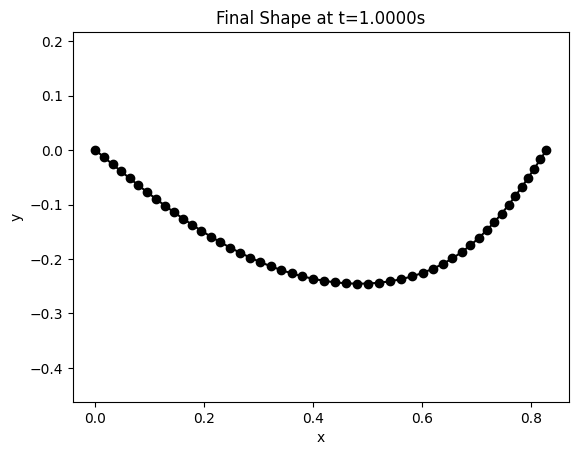

In [44]:
# Number of steps
Nsteps = round( totalTime / dt )

ctime = 0 # Current time

# Store the y-coordinate of the middle node, its velocity, and the angle
all_pos = np.zeros(Nsteps)
all_vel = np.zeros(Nsteps)
mid_angle = np.zeros(Nsteps)
max_y_displacement = np.zeros(Nsteps) # Store maximum vertical displacement

# Loop over the time steps
for timeStep in range(Nsteps): # Start from 0 to include initial state

  q_new, error = objfun(q0, u0, dt, tol, maximum_iter, m, mMat, EI, EA, W, C,
                        deltaL, free_index)
  if error < 0:
    print('Could not converge.')
    break

  u_new = (q_new - q0) / dt # New velocity


  ctime += dt # Update current time

  # Save information about the middle node
  all_pos[timeStep] = q_new[2*midNode-1] # y coordinate of middle node
  all_vel[timeStep] = u_new[2*midNode-1] # y velocity of middle node
  # Calculate turning angle at the middle node using dot product of adjacent segments
  vec1 = q_new[2*(midNode-1):2*midNode] - q_new[2*(midNode-2):2*(midNode-1)]
  vec2 = q_new[2*midNode:2*(midNode+1)] - q_new[2*(midNode-1):2*midNode]
  # Ensure vectors are 3D for cross product
  vec1_3d = np.append(vec1, 0)
  vec2_3d = np.append(vec2, 0)

  mid_angle[timeStep] =  np.degrees( np.arctan2(np.linalg.norm( np.cross(vec1_3d, vec2_3d)), np.dot(vec1_3d, vec2_3d)) )

  # Calculate and store maximum vertical displacement
  y_coords = q_new[1::2] # Get all y-coordinates
  max_y_displacement[timeStep] = np.min(y_coords) # Assuming downward displacement is negative


  q0 = q_new.copy() # New position becomes old position
  u0 = u_new.copy() # New velocity becomes old velocity

  # Plot
  if timeStep % plotStep == 0:
    x_arr = q_new[::2] # q[0], q[2], q[4]
    y_arr = q_new[1::2] # q[1], q[3], q[5]

    h1 = plt.figure(1)
    plt.clf() # Clear current figure
    plt.plot(x_arr, y_arr, 'ko-')
    plt.title(f't={ctime:.4f}s')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')


# Display the final shape after the loop
x_arr = q_new[::2]
y_arr = q_new[1::2]
h1 = plt.figure(1)
plt.clf()
plt.plot(x_arr, y_arr, 'ko-')
plt.title(f'Final Shape at t={ctime:.4f}s')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

## **HW 3 **

## Modify boundary conditions


In [45]:
import numpy as np

# Set of all DOFs
all_DOFs = np.arange(ndof)

# Fixed DOFs: first node (x and y), and middle node (x and y)
fixed_index = np.array([0, 1, 2 * midNode - 2, 2 * midNode - 1])

# Free index
free_index = np.setdiff1d(all_DOFs, fixed_index)

## Implement prescribed motion



In [46]:
def objfun(q_old, u_old, dt, tol, maximum_iter,
           m, mMat, # inertia
           EI, EA, # elastic stiffness
           W, C, # external force
           deltaL,
           free_index,
           fixed_index, # Add fixed_index to the arguments
           prescribed_q): # Add prescribed_q to the arguments

  q_new = q_old.copy() # Guess solution
  q_new[fixed_index] = prescribed_q # Set fixed DOFs to prescribed values

  # Newton Raphson
  iter_count = 0 # number of iterations
  error = tol * 10 # error
  flag = 1 # if flag = 1, it is a good solution

  while error > tol:
    # Inertia
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    J_inertia = mMat / dt ** 2

    # Elastic forces: Stretching and Bending
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL)
    F_elastic = Fs + Fb
    J_elastic = Js + Jb

    # External forces
    # Viscous force
    Fv = - C @ ( q_new - q_old ) / dt
    Jv = - C / dt

    # Equations of motion
    f = F_inertia - F_elastic - Fv - W
    J = J_inertia - J_elastic - Jv

    # Select only the free DOFs for the system of equations
    f_free = f[free_index]
    J_free = J[np.ix_(free_index, free_index)]

    # Newton's update (only for FREE DOFs)
    dq_free = np.linalg.solve(J_free, f_free)
    q_new[free_index] = q_new[free_index] - dq_free

    # Get the error (based on free DOFs)
    # Recalculate the forces with the updated q_new to get the error
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL)
    F_elastic = Fs + Fb
    Fv = - C @ ( q_new - q_old ) / dt
    f = F_inertia - F_elastic - Fv - W
    error = np.linalg.norm(f[free_index])


    # Update the iteration number
    iter_count += 1
    if iter_count > maximum_iter:
      flag = -1 # Return with an error signal
      print("Maximum number of iterations reached.")
      return q_new, flag

    # u_new = (q_new - q_old) / dt # Velocity
  return q_new, flag

## Update time stepping loop


Time: 0.0000, Target x: 0.5000, Target y: -0.0000


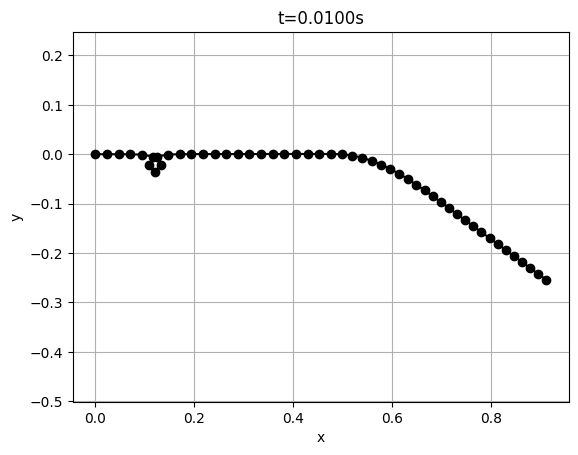

Time: 0.0100, Target x: 0.4999, Target y: -0.0079
Time: 0.0200, Target x: 0.4998, Target y: -0.0157
Time: 0.0300, Target x: 0.4994, Target y: -0.0236
Time: 0.0400, Target x: 0.4990, Target y: -0.0314
Time: 0.0500, Target x: 0.4985, Target y: -0.0392
Time: 0.0600, Target x: 0.4978, Target y: -0.0471
Time: 0.0700, Target x: 0.4970, Target y: -0.0549
Time: 0.0800, Target x: 0.4961, Target y: -0.0627
Time: 0.0900, Target x: 0.4950, Target y: -0.0705
Time: 0.1000, Target x: 0.4938, Target y: -0.0782


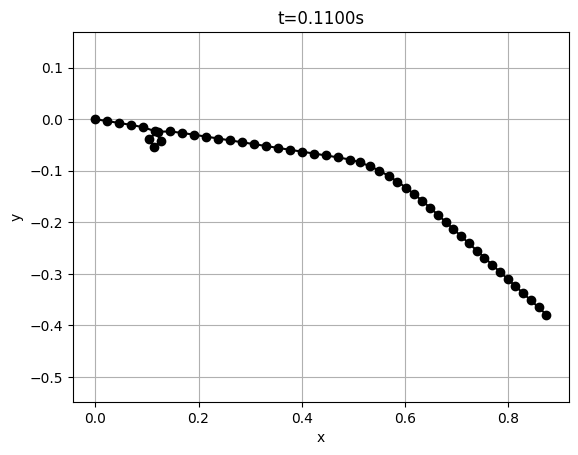

Time: 0.1100, Target x: 0.4926, Target y: -0.0860
Time: 0.1200, Target x: 0.4911, Target y: -0.0937
Time: 0.1300, Target x: 0.4896, Target y: -0.1014
Time: 0.1400, Target x: 0.4880, Target y: -0.1091
Time: 0.1500, Target x: 0.4862, Target y: -0.1167
Time: 0.1600, Target x: 0.4843, Target y: -0.1243
Time: 0.1700, Target x: 0.4823, Target y: -0.1319
Time: 0.1800, Target x: 0.4801, Target y: -0.1395
Time: 0.1900, Target x: 0.4779, Target y: -0.1470
Time: 0.2000, Target x: 0.4755, Target y: -0.1545


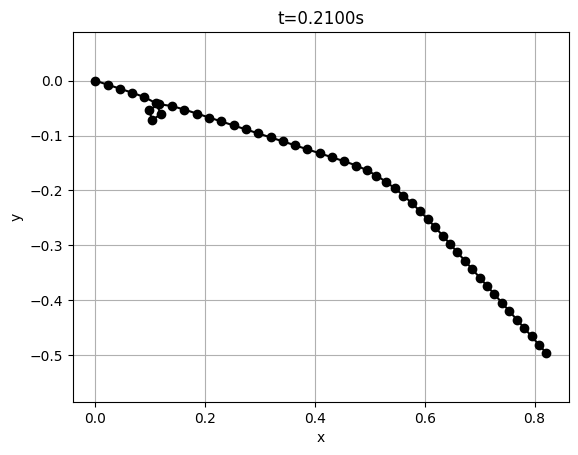

Time: 0.2100, Target x: 0.4730, Target y: -0.1620
Time: 0.2200, Target x: 0.4704, Target y: -0.1694
Time: 0.2300, Target x: 0.4677, Target y: -0.1767
Time: 0.2400, Target x: 0.4649, Target y: -0.1841
Time: 0.2500, Target x: 0.4619, Target y: -0.1913
Time: 0.2600, Target x: 0.4589, Target y: -0.1986
Time: 0.2700, Target x: 0.4557, Target y: -0.2058
Time: 0.2800, Target x: 0.4524, Target y: -0.2129
Time: 0.2900, Target x: 0.4490, Target y: -0.2200
Time: 0.3000, Target x: 0.4455, Target y: -0.2270


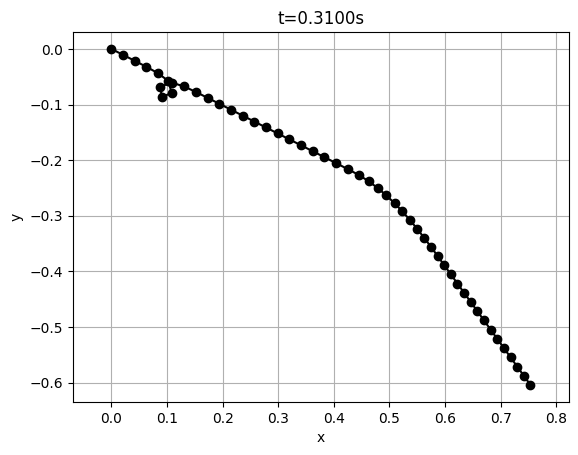

Time: 0.3100, Target x: 0.4419, Target y: -0.2340
Time: 0.3200, Target x: 0.4382, Target y: -0.2409
Time: 0.3300, Target x: 0.4343, Target y: -0.2477
Time: 0.3400, Target x: 0.4304, Target y: -0.2545
Time: 0.3500, Target x: 0.4263, Target y: -0.2612
Time: 0.3600, Target x: 0.4222, Target y: -0.2679
Time: 0.3700, Target x: 0.4179, Target y: -0.2745
Time: 0.3800, Target x: 0.4135, Target y: -0.2810
Time: 0.3900, Target x: 0.4091, Target y: -0.2875
Time: 0.4000, Target x: 0.4045, Target y: -0.2939


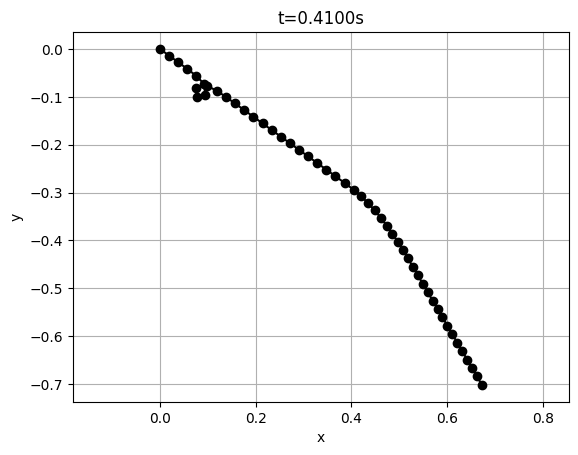

Time: 0.4100, Target x: 0.3998, Target y: -0.3002
Time: 0.4200, Target x: 0.3951, Target y: -0.3065
Time: 0.4300, Target x: 0.3902, Target y: -0.3126
Time: 0.4400, Target x: 0.3853, Target y: -0.3187
Time: 0.4500, Target x: 0.3802, Target y: -0.3247
Time: 0.4600, Target x: 0.3751, Target y: -0.3307
Time: 0.4700, Target x: 0.3698, Target y: -0.3365
Time: 0.4800, Target x: 0.3645, Target y: -0.3423
Time: 0.4900, Target x: 0.3591, Target y: -0.3480
Time: 0.5000, Target x: 0.3536, Target y: -0.3536


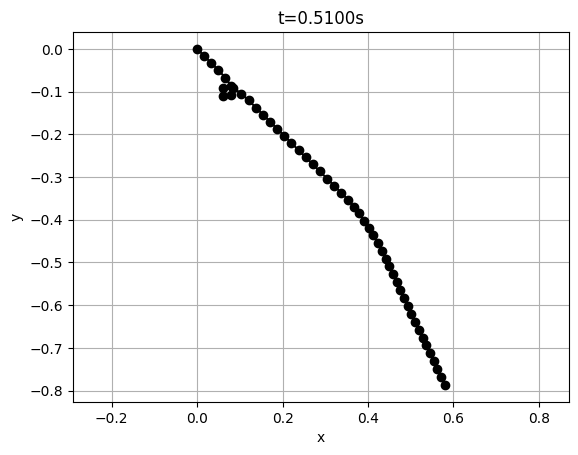

Time: 0.5100, Target x: 0.3480, Target y: -0.3591
Time: 0.5200, Target x: 0.3423, Target y: -0.3645
Time: 0.5300, Target x: 0.3365, Target y: -0.3698
Time: 0.5400, Target x: 0.3307, Target y: -0.3751
Time: 0.5500, Target x: 0.3247, Target y: -0.3802
Time: 0.5600, Target x: 0.3187, Target y: -0.3853
Time: 0.5700, Target x: 0.3126, Target y: -0.3902
Time: 0.5800, Target x: 0.3065, Target y: -0.3951
Time: 0.5900, Target x: 0.3002, Target y: -0.3998
Time: 0.6000, Target x: 0.2939, Target y: -0.4045


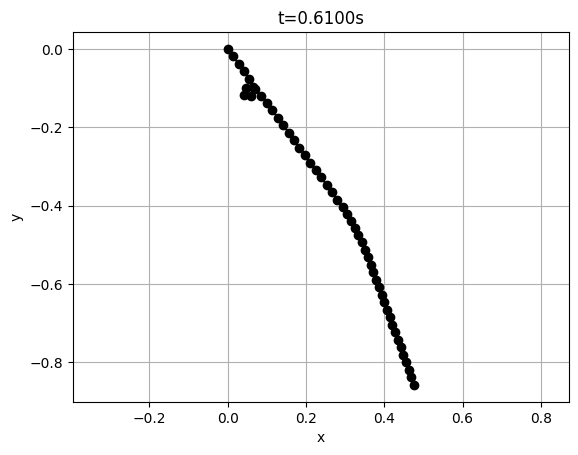

Time: 0.6100, Target x: 0.2875, Target y: -0.4091
Time: 0.6200, Target x: 0.2810, Target y: -0.4135
Time: 0.6300, Target x: 0.2745, Target y: -0.4179
Time: 0.6400, Target x: 0.2679, Target y: -0.4222
Time: 0.6500, Target x: 0.2612, Target y: -0.4263
Time: 0.6600, Target x: 0.2545, Target y: -0.4304
Time: 0.6700, Target x: 0.2477, Target y: -0.4343
Time: 0.6800, Target x: 0.2409, Target y: -0.4382
Time: 0.6900, Target x: 0.2340, Target y: -0.4419
Time: 0.7000, Target x: 0.2270, Target y: -0.4455


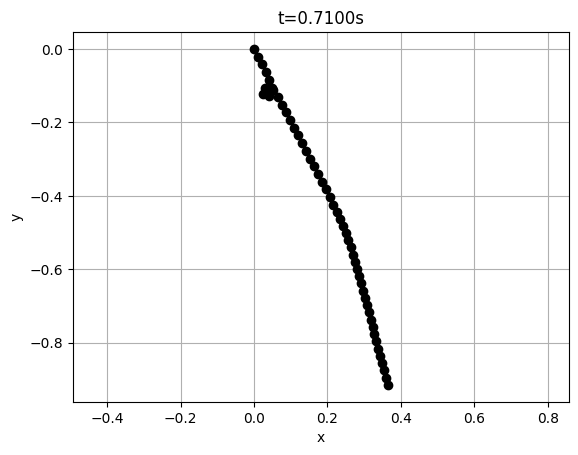

Time: 0.7100, Target x: 0.2200, Target y: -0.4490
Time: 0.7200, Target x: 0.2129, Target y: -0.4524
Time: 0.7300, Target x: 0.2058, Target y: -0.4557
Time: 0.7400, Target x: 0.1986, Target y: -0.4589
Time: 0.7500, Target x: 0.1913, Target y: -0.4619
Time: 0.7600, Target x: 0.1841, Target y: -0.4649
Time: 0.7700, Target x: 0.1767, Target y: -0.4677
Time: 0.7800, Target x: 0.1694, Target y: -0.4704
Time: 0.7900, Target x: 0.1620, Target y: -0.4730
Time: 0.8000, Target x: 0.1545, Target y: -0.4755


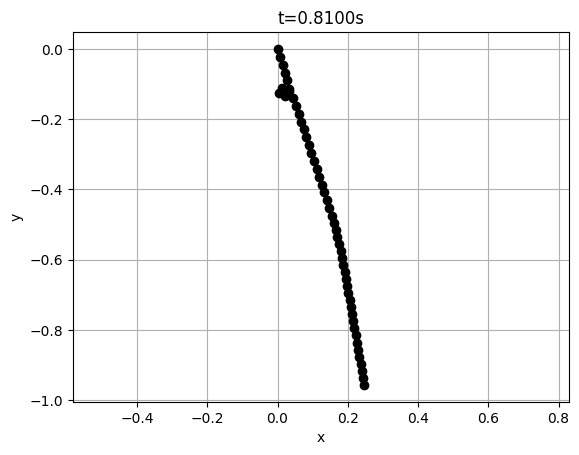

Time: 0.8100, Target x: 0.1470, Target y: -0.4779
Time: 0.8200, Target x: 0.1395, Target y: -0.4801
Time: 0.8300, Target x: 0.1319, Target y: -0.4823
Time: 0.8400, Target x: 0.1243, Target y: -0.4843
Time: 0.8500, Target x: 0.1167, Target y: -0.4862
Time: 0.8600, Target x: 0.1091, Target y: -0.4880
Time: 0.8700, Target x: 0.1014, Target y: -0.4896
Time: 0.8800, Target x: 0.0937, Target y: -0.4911
Time: 0.8900, Target x: 0.0860, Target y: -0.4926
Time: 0.9000, Target x: 0.0782, Target y: -0.4938


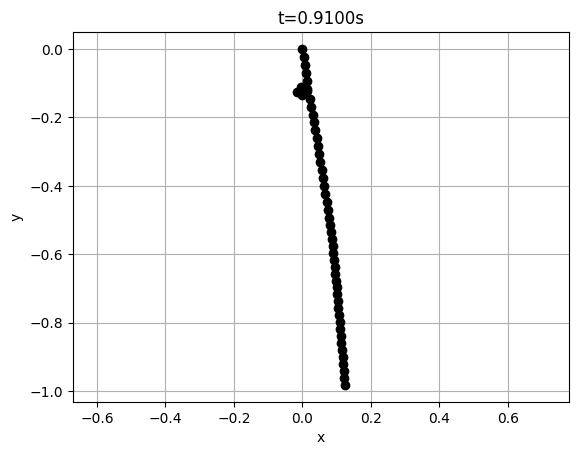

Time: 0.9100, Target x: 0.0705, Target y: -0.4950
Time: 0.9200, Target x: 0.0627, Target y: -0.4961
Time: 0.9300, Target x: 0.0549, Target y: -0.4970
Time: 0.9400, Target x: 0.0471, Target y: -0.4978
Time: 0.9500, Target x: 0.0392, Target y: -0.4985
Time: 0.9600, Target x: 0.0314, Target y: -0.4990
Time: 0.9700, Target x: 0.0236, Target y: -0.4994
Time: 0.9800, Target x: 0.0157, Target y: -0.4998
Time: 0.9900, Target x: 0.0079, Target y: -0.4999


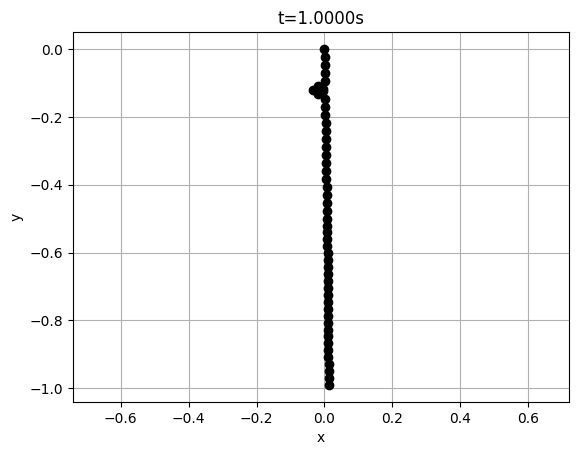

In [65]:
# Prescribed trajectory for the middle node (x and y coordinates as functions of time)

# Time stepping loop
Nsteps = round( totalTime / dt )
ctime = 0 # Current time

Nsteps = round( totalTime / dt ) # Recalculate Nsteps based on the new dt
# Loop over the time steps
for timeStep in range(Nsteps):

  # Define the target x and y coordinates for the middle node as functions of time (ctime)
  target_mid_x =  0.5 * RodLength * np.cos(ctime * np.pi / 2*totalTime)
  target_mid_y = -0.5 * RodLength * np.sin(ctime * np.pi / 2*totalTime)

  # Print the target coordinates
  print(f"Time: {ctime:.4f}, Target x: {target_mid_x:.4f}, Target y: {target_mid_y:.4f}")


  # Create the prescribed_q array for the fixed DOFs
  # Fixed DOFs: first node (x and y), middle node (x and y)
  # x-coordinates remain at their initial values, y-coordinate of first node remains at initial value
  prescribed_q = np.array([nodes[0, 0], nodes[0, 1], target_mid_x, target_mid_y])

  # Call the updated objfun with fixed_index and prescribed_q
  q_new, error = objfun(q0, u0, dt, tol, maximum_iter, m, mMat, EI, EA, W, C,
                        deltaL, free_index, fixed_index, prescribed_q)
  if error < 0:
    print(f'Could not converge at time step {timeStep}.')
    break

  u_new = (q_new - q0) / dt # New velocity

  ctime += dt # Update current time

  q0 = q_new.copy() # New position becomes old position
  u0 = u_new.copy() # New velocity becomes old velocity

  # Plot the current shape less frequently
  if timeStep % (Nsteps // 10) == 0 or timeStep == Nsteps - 1: # Plot 10 times + final step
    x_arr = q_new[::2] # q[0], q[2], q[4]
    y_arr = q_new[1::2] # q[1], q[3], q[5]

    h1 = plt.figure(1)
    plt.clf() # Clear current figure
    plt.plot(x_arr, y_arr, 'ko-')
    plt.title(f't={ctime:.4f}s')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.grid(True)
    plt.show() # Display the plot


Plot the x and y coordinates of the last node and the angle of the last segment over time.

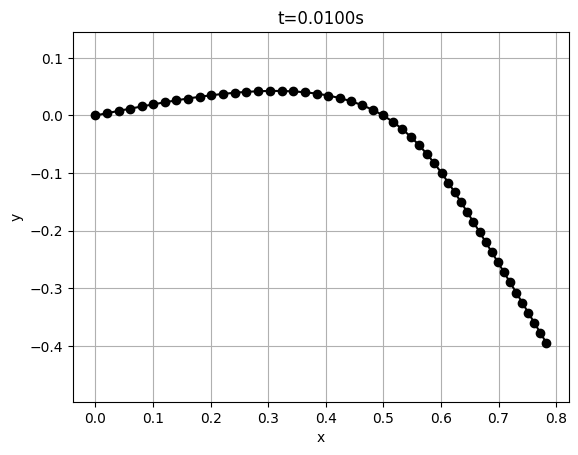

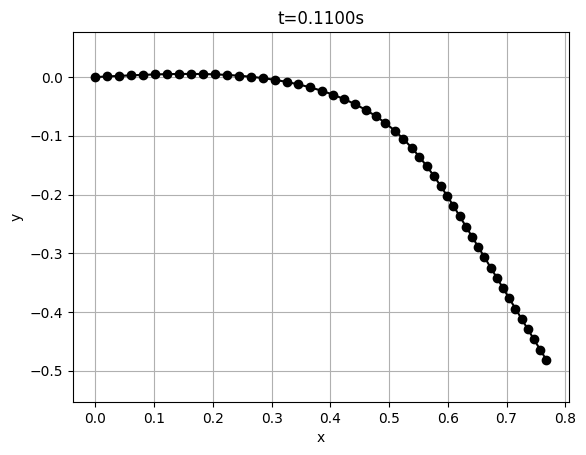

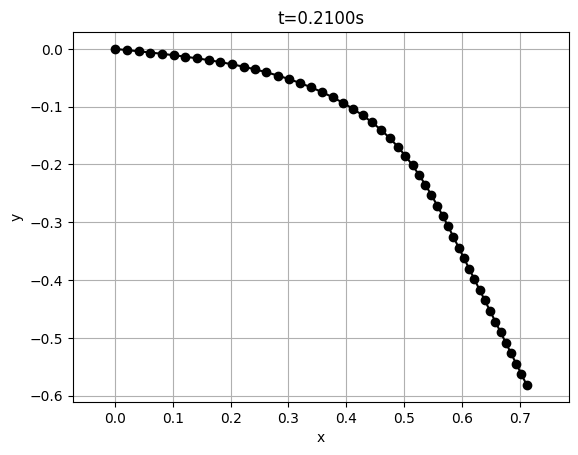

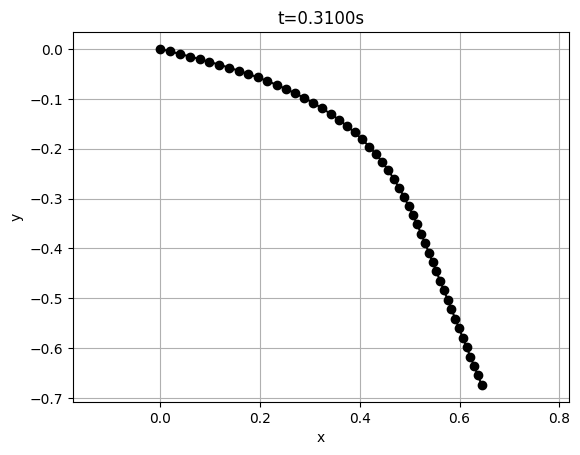

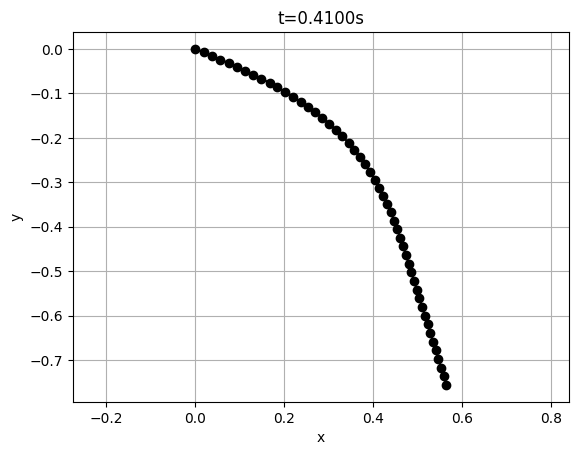

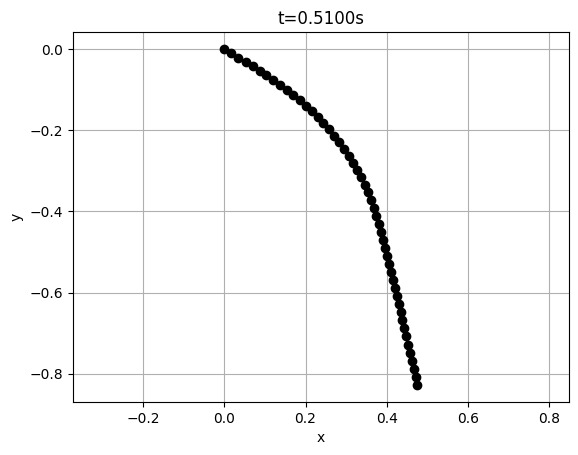

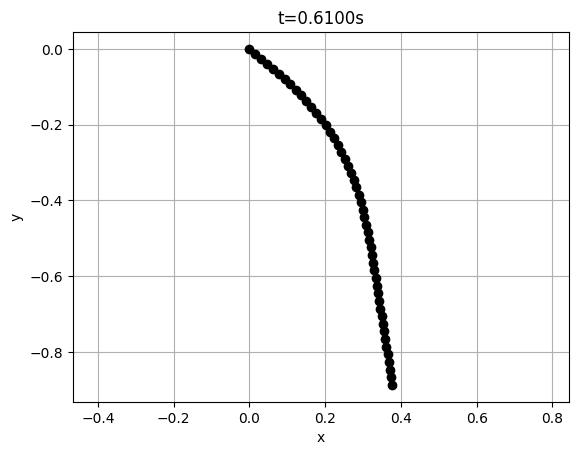

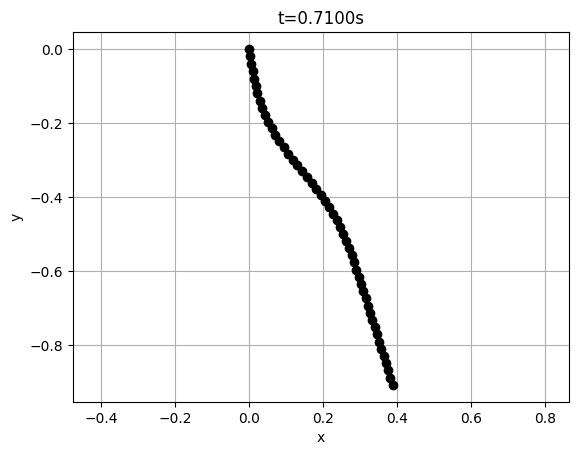

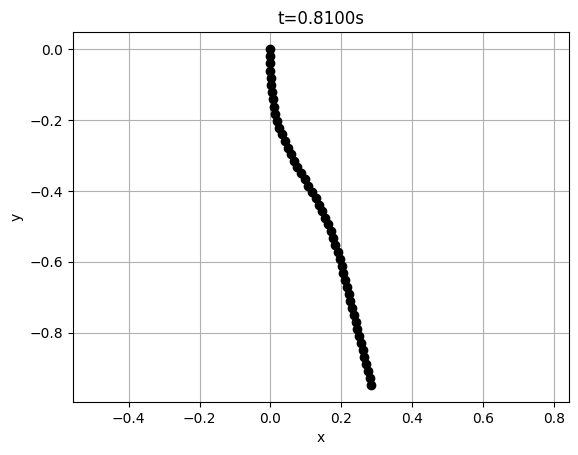

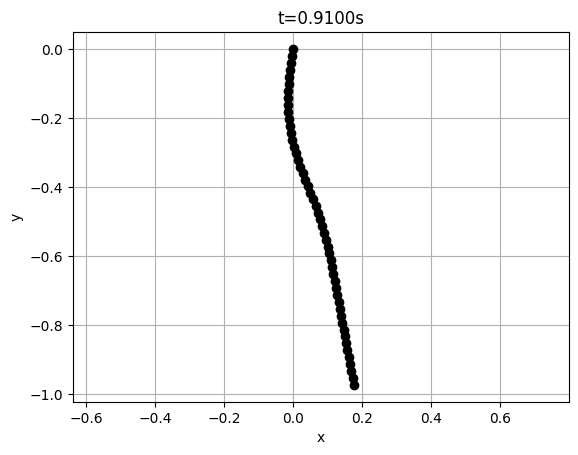

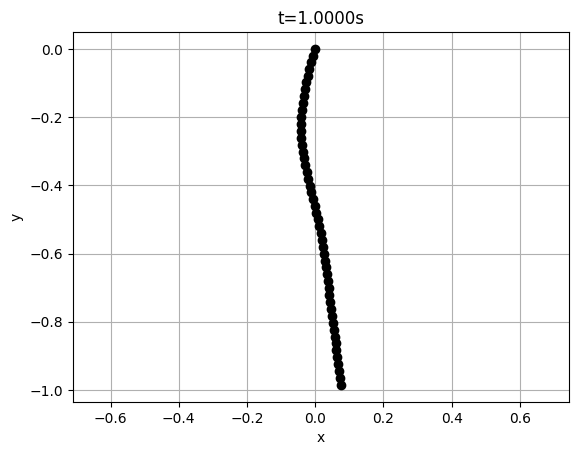

In [66]:
# Initialize lists to store the position and angle of the last node/segment
last_node_x = []
last_node_y = []
last_segment_angle = []

# Time stepping loop
Nsteps = round( totalTime / dt )
ctime = 0 # Current time

# Loop over the time steps
for timeStep in range(Nsteps):

  # Define the target x and y coordinates for the middle node as functions of time (ctime)
  # You can replace these with your desired functions of time
  target_mid_x =  0.5 * RodLength * np.cos(ctime * np.pi / 2*totalTime)
  target_mid_y = -0.5 * RodLength * np.sin(ctime * np.pi / 2*totalTime)

  # Create the prescribed_q array for the fixed DOFs
  # Fixed DOFs: first node (x and y), middle node (x and y)
  # x-coordinates remain at their initial values, y-coordinate of first node remains at initial value
  prescribed_q = np.array([nodes[0, 0], nodes[0, 1], target_mid_x, target_mid_y])

  # Call the updated objfun with fixed_index and prescribed_q
  q_new, error = objfun(q0, u0, dt, tol, maximum_iter, m, mMat, EI, EA, W, C,
                        deltaL, free_index, fixed_index, prescribed_q)
  if error < 0:
    print(f'Could not converge at time step {timeStep}.')
    break

  u_new = (q_new - q0) / dt # New velocity

  ctime += dt # Update current time

  # Store the x and y coordinates of the last node
  last_node_x.append(q_new[2*nv-2])
  last_node_y.append(q_new[2*nv-1])

  # Calculate and store the angle of the last segment
  last_segment_vec = q_new[2*nv-2:2*nv] - q_new[2*nv-4:2*nv-2]
  # Calculate the angle with respect to the positive x-axis
  angle_rad = np.arctan2(last_segment_vec[1], last_segment_vec[0])
  last_segment_angle.append(np.degrees(angle_rad))

  q0 = q_new.copy() # New position becomes old position
  u0 = u_new.copy() # New velocity becomes old velocity

  # Plot the current shape less frequently
  if timeStep % (Nsteps // 10) == 0 or timeStep == Nsteps - 1: # Plot 10 times + final step
    x_arr = q_new[::2] # q[0], q[2], q[4]
    y_arr = q_new[1::2] # q[1], q[3], q[5]

    h1 = plt.figure(1)
    plt.clf() # Clear current figure
    plt.plot(x_arr, y_arr, 'ko-')
    plt.title(f't={ctime:.4f}s')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.grid(True)
    plt.show() # Display the plot


## Plot

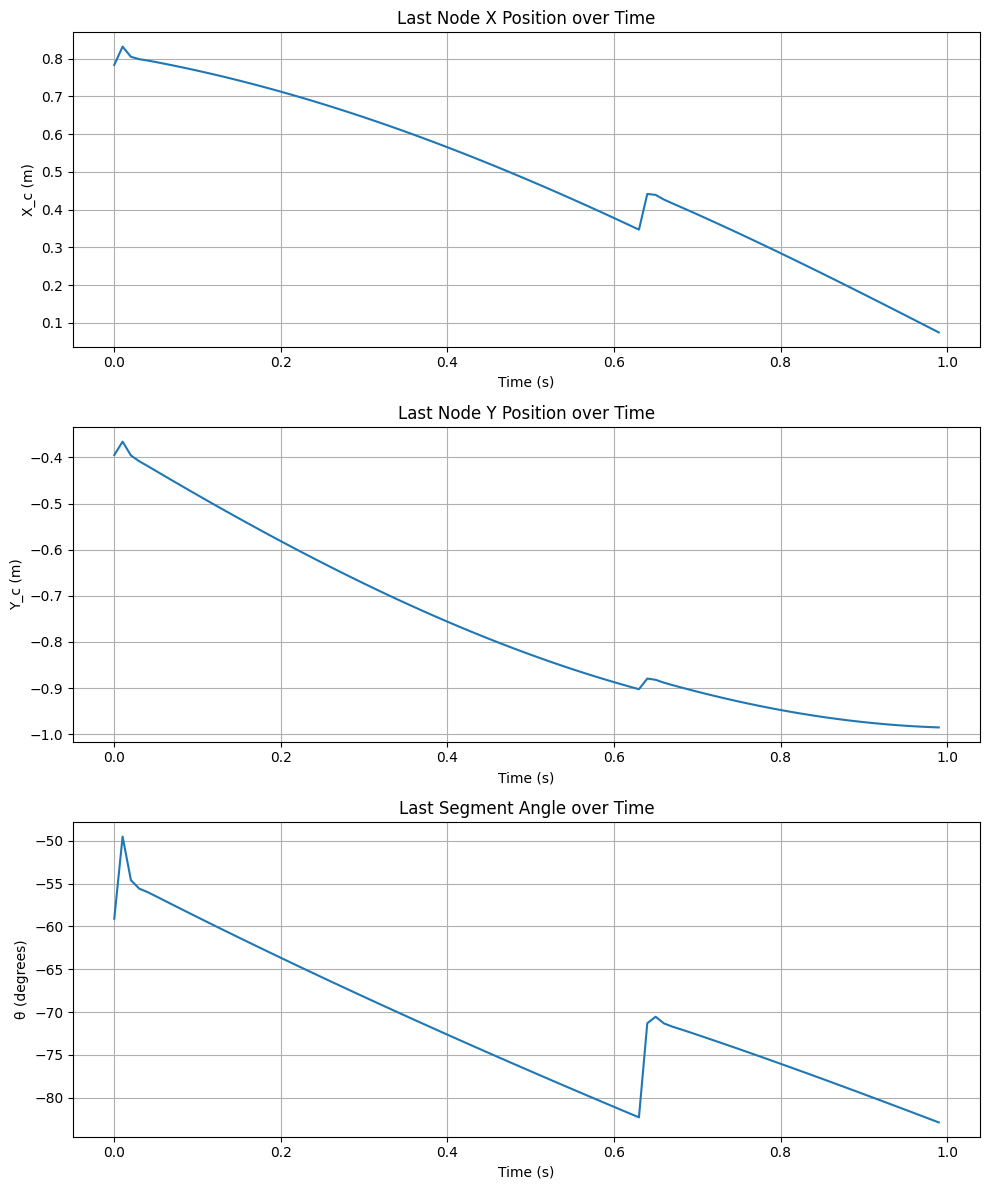

In [68]:
# Create a time array
time_array = np.arange(Nsteps) * dt

# Create a figure with three subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Plot Last Node X Position
axes[0].plot(time_array, last_node_x)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('X_c (m)')
axes[0].set_title('Last Node X Position over Time')
axes[0].grid(True)

# Plot Last Node Y Position
axes[1].plot(time_array, last_node_y)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Y_c (m)')
axes[1].set_title('Last Node Y Position over Time')
axes[1].grid(True)

# Plot Last Segment Angle
axes[2].plot(time_array, last_segment_angle)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('θ (degrees)')
axes[2].set_title('Last Segment Angle over Time')
axes[2].grid(True)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()